# **Machine Learning for Natural Language Processing (NLP)**

`Covered by Shafin Ahmed_232-15-184`

---

## Covered Topic

| # | Topic | Technique |
|---|-------|-----------|
| 1 | Text Vectorization | Bag of Words (BoW) |
| 2 | Multilingual BoW | CountVectorizer with custom tokenizer |
| 3 | TF-IDF Representation | TfidfVectorizer |
| 4 | Dataset Loading | Pandas + Excel |
| 5 | Text Classification Pipeline | Logistic Regression + Cross-Validation |
| 6 | Model Evaluation | Accuracy, Precision, Recall, F1, Confusion Matrix |
| 7 | Model Comparison | Logistic Regression vs SVM vs Random Forest |





## Mount Google Drive

Before loading any datasets, we need to connect Google Drive to the Colab environment.

This gives us access to files stored in Drive (e.g., Excel datasets used later in the notebook).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bag of Words (BoW)

### What is Bag of Words?

**Bag of Words (BoW)** is one of the simplest and most widely used methods to convert text into numerical vectors.
It ignores word order and grammar, and simply counts how many times each word appears.

### How It Works

Given a corpus of documents, BoW:
1. Builds a **vocabulary** — a set of all unique words
2. Represents each document as a **word-count vector** over that vocabulary

### Formula

For a document $d$ and vocabulary word $w$:

$$\text{BoW}(d, w) = \text{count of } w \text{ in } d$$

### Example

| Sentence | cat | love | movie | this |
|----------|-----|------|-------|------|
| "I love this movie" | 0 | 1 | 1 | 1 |
| "I love this cat"   | 1 | 1 | 0 | 1 |

>  Words like "I" are removed as **stop words** by default in `CountVectorizer`.

In [3]:
from numpy import vectorize
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "I love this movie",
    "I love this cat"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(texts)

print("Vocabulary:")
print(vectorizer.vocabulary_)

print(vectorizer.get_feature_names_out())

print("\nVectorized Texts:")
print(X.toarray())

Vocabulary:
{'love': 1, 'this': 3, 'movie': 2, 'cat': 0}
['cat' 'love' 'movie' 'this']

Vectorized Texts:
[[0 1 1 1]
 [1 1 0 1]]


## TF-IDF Vectorization

### What is TF-IDF?

**TF-IDF** (Term Frequency–Inverse Document Frequency) improves upon BoW by **down-weighting** common words and **up-weighting** rare, informative words.

### Formulas

**Term Frequency (TF):**

$$TF(t, d) = \frac{\text{count of term } t \text{ in document } d}{\text{total terms in } d}$$

**Inverse Document Frequency (IDF):**

$$IDF(t) = \log\left(\frac{1 + N}{1 + df(t)}\right) + 1$$

**TF-IDF Score:**

$$\text{TF-IDF}(t, d) = TF(t, d) \times IDF(t)$$

Where:
- $N$ = total number of documents
- $df(t)$ = number of documents containing term $t$

### BoW vs TF-IDF

| Feature | Bag of Words | TF-IDF |
|---------|-------------|--------|
| Representation | Raw counts | Weighted scores |
| Common words | High weight  | Penalized  |
| Rare/unique words | No boost | Boosted  |
| Best use case | Simple baseline | Better for classification |

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [
    "মুভিটি খুব ভালো",
    "মুভিটি খুব বাজে"
]

vectorizer = TfidfVectorizer(
    tokenizer = lambda x: x.split(),
    token_pattern = None
)

X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

print("\nVectorized Texts:")
print(X.toarray())

['খুব' 'বাজে' 'ভালো' 'মুভিটি']

Vectorized Texts:
[[0.50154891 0.         0.70490949 0.50154891]
 [0.50154891 0.70490949 0.         0.50154891]]



## Extract Features & Labels (E-Commerce)

We split the dataframe into:
- **`X`** — the input features (raw comment text)
- **`y`** — the target labels (product tags/categories)

This is the standard `(X, y)` split used in all scikit-learn workflows.

In [6]:
import pandas as pd
import numpy as np

path=r"/content/E-commerce.xlsx"
df=pd.read_excel(path)
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,Name,Comment,Tag
0,Monirul Ahmed,"আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি?????...",Bad
1,Tanzil Ayon,আপনাদের প্রায়োরিটি স্টোর/ T10 এর আগের পণ্য গু...,Bad
2,HM Athir Al Azad,Order করেছি কিন্তু এখনো নোটিফিকেশন এর মাধ্যমে ...,Bad
3,মোহাম্মদ ইকবাল হোসাইন রুবেল,পেমেন্ট করতে চাইলে নিচের মেসেজ টা শো করছে।আমার...,Neutral
4,DrSheikh Rumi,msung M01s) এটা ৭ দিনের গ্যারান্টেড ডেলিভারির ...,Bad


In [7]:
X = df['Comment']
y = df['Tag']
X,y

(0      আদৌও কি আমার রিফান্ড পাবো, প্রিয় ই- ভালি?????...
 1      আপনাদের প্রায়োরিটি স্টোর/ T10 এর আগের পণ্য গু...
 2      Order করেছি কিন্তু এখনো নোটিফিকেশন এর মাধ্যমে ...
 3      পেমেন্ট করতে চাইলে নিচের মেসেজ টা শো করছে।আমার...
 4      msung M01s) এটা ৭ দিনের গ্যারান্টেড ডেলিভারির ...
                              ...                        
 944    শুধু চীন নয়, আরো দেশ থেকে আরো ক্রস বর্ডার পণ্...
 945    আমি দারাজ মূলকে ভালোবাসি কারণ 10% ক্যাশব্যাক +...
 946    দারাজমল 100% প্রামাণিক পণ্য ডেলিভারি দে .. আইখ...
 947    আজ অবধি, আল্লাহর রহমতে আমি দারাজ থেকে যতটা সম্...
 948    আগামি 10 বছর একটি দারাজ পৃথীবির পোটাক্তা কোনায...
 Name: Comment, Length: 949, dtype: object,
 0          Bad
 1          Bad
 2          Bad
 3      Neutral
 4          Bad
         ...   
 944    Neutral
 945       Good
 946       Good
 947       Good
 948    Neutral
 Name: Tag, Length: 949, dtype: object)

**We take another dataset to see the other task because tis dataset has some null values maybe. So we need to pre process this dataset at first**

## Load Social Media Sentiment Dataset

We now load a second dataset — **social media comments** with sentiment labels (e.g., Positive / Negative / Neutral).

This dataset will be used for all downstream classification and evaluation tasks.

In [8]:
df = pd.read_excel(r'/content/social_media_comment.xlsx')
df.head()

,Comment,Sentiment
0,কোনো সমস্যা নেই! আপনার মতামত প্রকাশ করতে হলে স...,Neutral
1,যোগা কিশোরী সম্পর্কেও আপনার অনুভূতি জানালে ভাল...,Neutral
2,সবচেয়ে বাজে হলো প্রিয়তমা। গল্প + dialogue +গ...,Negative
3,শাকিব খানের অভিনয় অসাধারণ এবং তার পরিবর্তিত l...,Positive
4,ছবির গল্পটি রোমাঞ্চকর এবং thrillerএর উপাদান যু...,Positive


## Extract Features & Labels (Social Media)

Again, we extract:
- **`X`** — comment text (input)
- **`y`** — sentiment label (target)

These will feed into the ML pipeline next.

In [9]:
X = df['Comment']
y = df['Sentiment']
X,y

(0       কোনো সমস্যা নেই! আপনার মতামত প্রকাশ করতে হলে স...
 1       যোগা কিশোরী সম্পর্কেও আপনার অনুভূতি জানালে ভাল...
 2       সবচেয়ে বাজে হলো প্রিয়তমা। গল্প + dialogue +গ...
 3       শাকিব খানের অভিনয় অসাধারণ এবং তার পরিবর্তিত l...
 4       ছবির গল্পটি রোমাঞ্চকর এবং thrillerএর উপাদান যু...
                               ...                        
 8326    অভিনয়ের অনেক কিছুই হালকা লাগছিল, কিছু দৃশ্যে ...
 8327    গল্পটা কোথাও গলদ ছিল, অনেক কিছু অবাস্তব মনে হয...
 8328    শাবনুরের চরিত্রটা আমার কাছে খুবই অপ্রাসঙ্গিক ম...
 8329    কিছু সংলাপ অনেক ঝাল মনে হয়েছে, আরও মজার হতে প...
 8330     পুরো cinema দেখতে দেখতে ক্লান্ত হয়ে গিয়েছিলাম।
 Name: Comment, Length: 8331, dtype: object,
 0        Neutral
 1        Neutral
 2       Negative
 3       Positive
 4       Positive
           ...   
 8326    Negative
 8327    Negative
 8328    Negative
 8329     Neutral
 8330    Negative
 Name: Sentiment, Length: 8331, dtype: object)



##  Build ML Pipeline & Run Cross-Validation (Logistic Regression)

### What is a Pipeline?

A `Pipeline` chains preprocessing and modeling steps so that:
- The vectorizer is **fit only on training data** (no data leakage)
- The entire process is **reproducible and clean**
- Convert text into numbers **(CountVectorizer)**
- Train the model using those numbers **(Logistic Regression)**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pipeline = Pipeline([
    (
        "tfidf",
        CountVectorizer(
          tokenizer = lambda x: x.split(),
          token_pattern = None
      )
    ),
    (
        "model",
        LogisticRegression(max_iter=1000, random_state=42)
    )
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv = kfold
)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


##Inspect Predictions

A quick look at the raw predicted labels array `y_pred` to verify the cross-validation ran successfully.

In [12]:
y_pred

array(['Negative', 'Negative', 'Positive', ..., 'negative', 'Neutral',
       'Positive'], dtype=object)

## Evaluation Metrics

### Key Classification Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Overall correctness |
| **Precision** | $\frac{TP}{TP + FP}$ | Of predicted positives, how many are correct |
| **Recall** | $\frac{TP}{TP + FN}$ | Of actual positives, how many were found |
| **F1 Score** | $\frac{2 \times P \times R}{P + R}$ | Harmonic mean of Precision & Recall |

> We use `average='weighted'` to account for **class imbalance** — each class contributes proportionally to its support (sample count).

In [24]:
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='weighted')
recall = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6643860280878646
Precision: 0.7046374920727435
Recall: 0.6643860280878646
F1 Score: 0.6802935911303029


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Full Classification Report

`classification_report` gives a **per-class breakdown** of Precision, Recall, and F1 Score, along with macro and weighted averages.

This is more informative than a single accuracy number, especially for **multi-class** or **imbalanced** datasets.

In [14]:
class_report = classification_report(y, y_pred)
print(class_report)

                                                     precision    recall  f1-score   support

                 Mixed (Negative + Slight Positive)       0.00      0.00      0.00         1
                         Mixed (Neutral + Positive)       0.00      0.00      0.00         1
                        Mixed (Positive + Negative)       0.00      0.00      0.00         3
                 Mixed (Positive + Slight Negative)       0.00      0.00      0.00         3
     Mixed (Positive for acting, Negative for plot)       0.00      0.00      0.00         1
Mixed (Positive for last 20 mins, Negative overall)       0.00      0.00      0.00         1
  Mixed (Positive for শরিফুল রাজ, Negative overall)       0.00      0.00      0.00         1
                 Mixed (Slight Negative + Positive)       0.00      0.00      0.00        17
                Mixed (Slight Positive + Skeptical)       0.00      0.00      0.00         1
                                           Negative       0.65      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))




## Inspect Unique Sentiment Labels

Let's check what distinct sentiment classes exist in the dataset.


In [15]:
df['Sentiment'].unique()

array(['Neutral', 'Negative', 'Positive',
       'Mixed (Positive for last 20 mins, Negative overall)',
       'Mixed (Positive + Slight Negative)',
       'Mixed (Positive + Negative)', 'Mixed (Neutral + Positive)',
       'Mixed (Negative + Slight Positive)',
       'Mixed (Slight Negative + Positive)',
       'Mixed (Slight Positive + Skeptical)',
       'Mixed (Positive for শরিফুল রাজ, Negative overall)',
       'Mixed (Positive for acting, Negative for plot)', 'negative',
       'neutral', 'positive', 'mixed'], dtype=object)



## Confusion Matrix (Raw Values)

The **confusion matrix** shows how predictions compare to actual labels:

$$C_{ij} = \text{number of samples of class } i \text{ predicted as class } j$$

- **Diagonal** = correct predictions
- **Off-diagonal** = misclassifications

In [16]:
cm = confusion_matrix(y, y_pred)
print(cm)

[[   0    0    0    0    0    0    0    0    0    1    0    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    1    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    1    2    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    3    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    1    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    1    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    1    0    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0    2    9    5    0    1
     0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    1    0    0
     0    0]
 [   0    0    0    0    0    0    0    0    0 1231  245  187    0  123
     0    8]
 [   0    0    0    0    0    0    0    0    0  228 2386  151    0   26
     4   12]
 [   0    0    0    0    0    0    0    0    0  106  113 2170    



## Confusion Matrix Visualization

Visualizing the confusion matrix as a heatmap makes it easier to spot:
- Which classes are **most confused** with each other
- Where the model **performs best / worst**

We use `ConfusionMatrixDisplay` with `matplotlib` for a clean, labeled plot.

/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png")
/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig("confusion_matrix.png")
/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png")
/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png")
/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png")
/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png")
/tmp/ipykernel_1656/4196843226.py:13: UserWarning: Glyph 

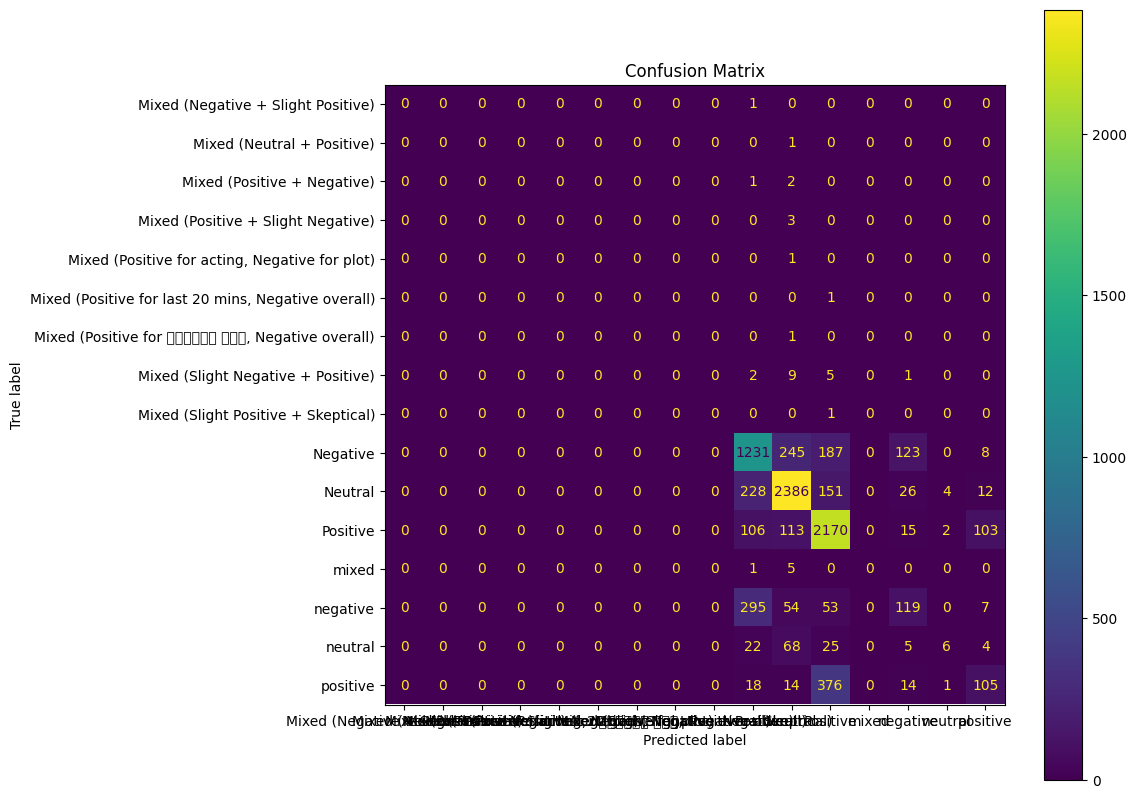

In [19]:
import matplotlib.pyplot as plt

label = np.unique(y)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label
  )

fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax = ax)
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

## **Model Comparison:** Logistic Regression vs SVM vs Random Forest

### Why Compare Multiple Models?

No single model wins on every dataset. We evaluate three classifiers:

| Model | Type | Strength |
|-------|------|----------|
| **Logistic Regression** | Linear | Fast, interpretable, great baseline |
| **Linear SVC** | Linear (margin-based) | Excellent for high-dimensional text data |
| **Random Forest** | Ensemble (tree-based) | Handles non-linearity, feature interactions |

### Process

For each model, we:
1. Build a pipeline: `CountVectorizer → Classifier`
2. Run **5-fold Stratified Cross-Validation**
3. Report Accuracy, Precision, Recall, and F1

> The model with the highest weighted F1 on this dataset is the best candidate for deployment.

Model: Logistic Regression
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_

Accuracy: 0.7222422278237907
Precision: 0.6962296994682033
Recall: 0.7222422278237907
F1 Score: 0.7003755602798143


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/di

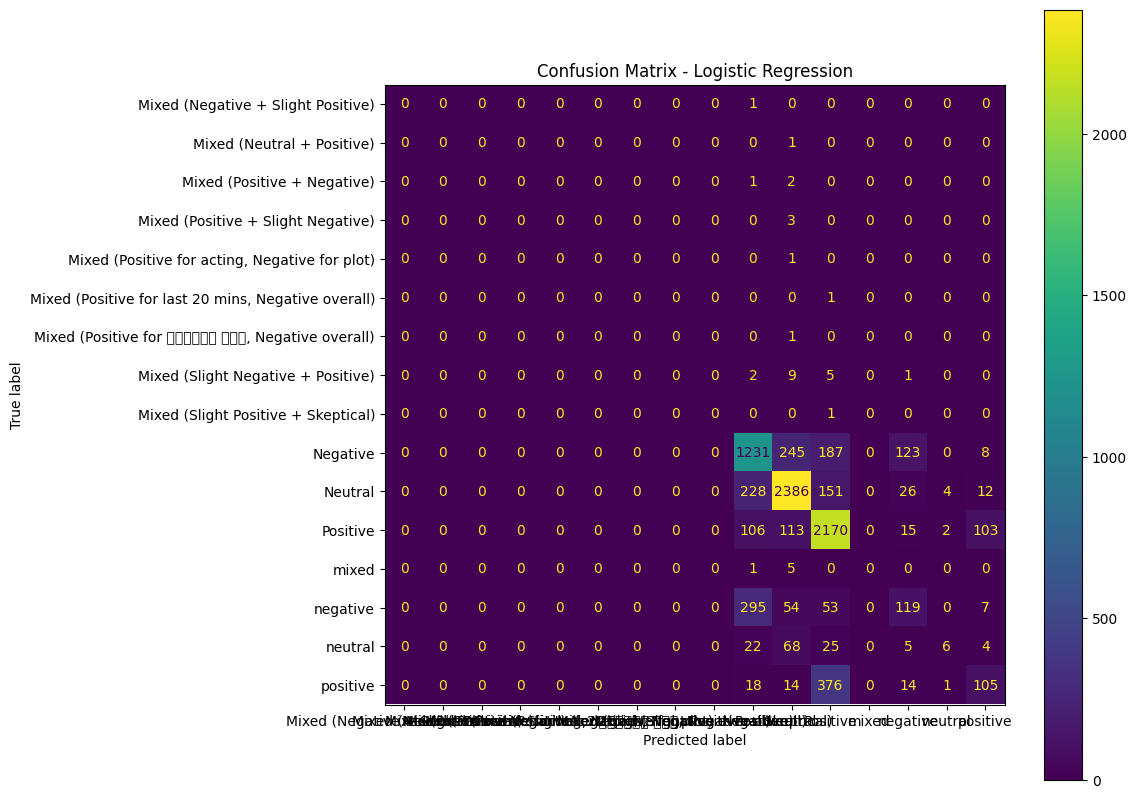

Model: Linear SVC
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_

Accuracy: 0.6987156403793062
Precision: 0.6850465217491108
Recall: 0.6987156403793062
F1 Score: 0.6909578485767741


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/di

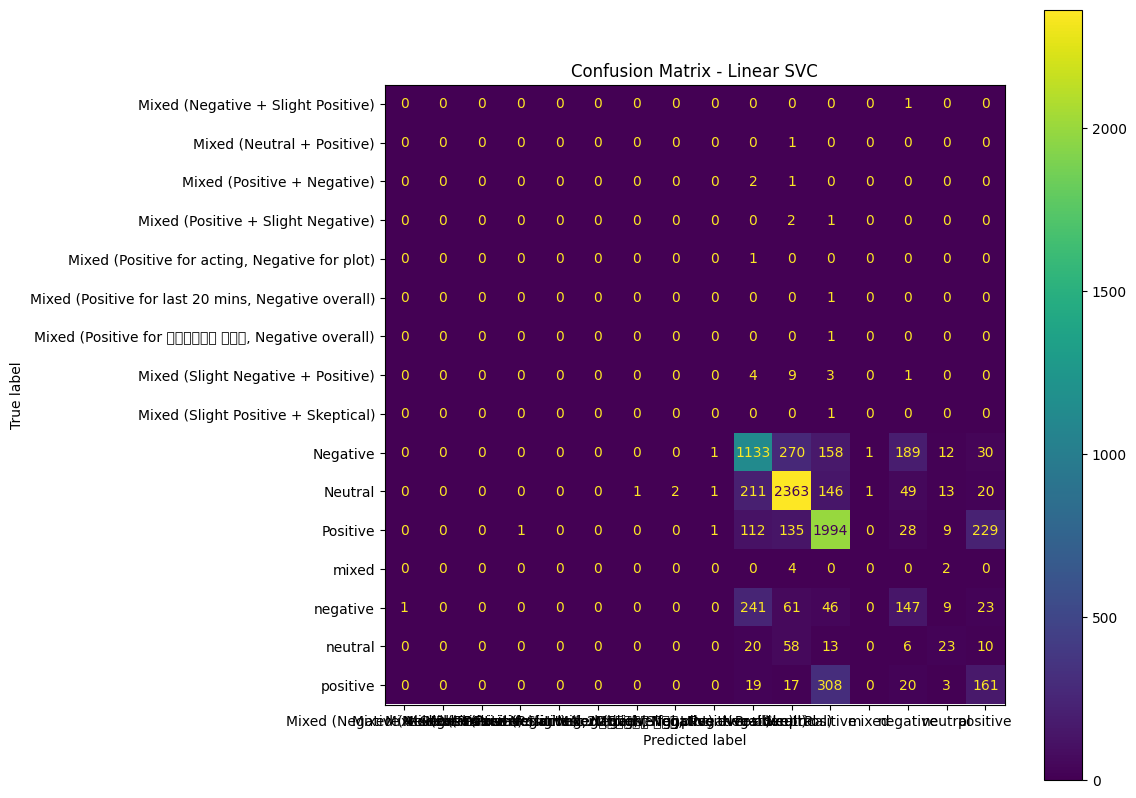

Model: Random Forest
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.7180410514944184
Precision: 0.718996379039591
Recall: 0.7180410514944184
F1 Score: 0.681652445179849


/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2475 (\N{BENGALI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion_matrix_{model_name}.png")
/tmp/ipykernel_1656/3504855499.py:44: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.savefig(f"confusion

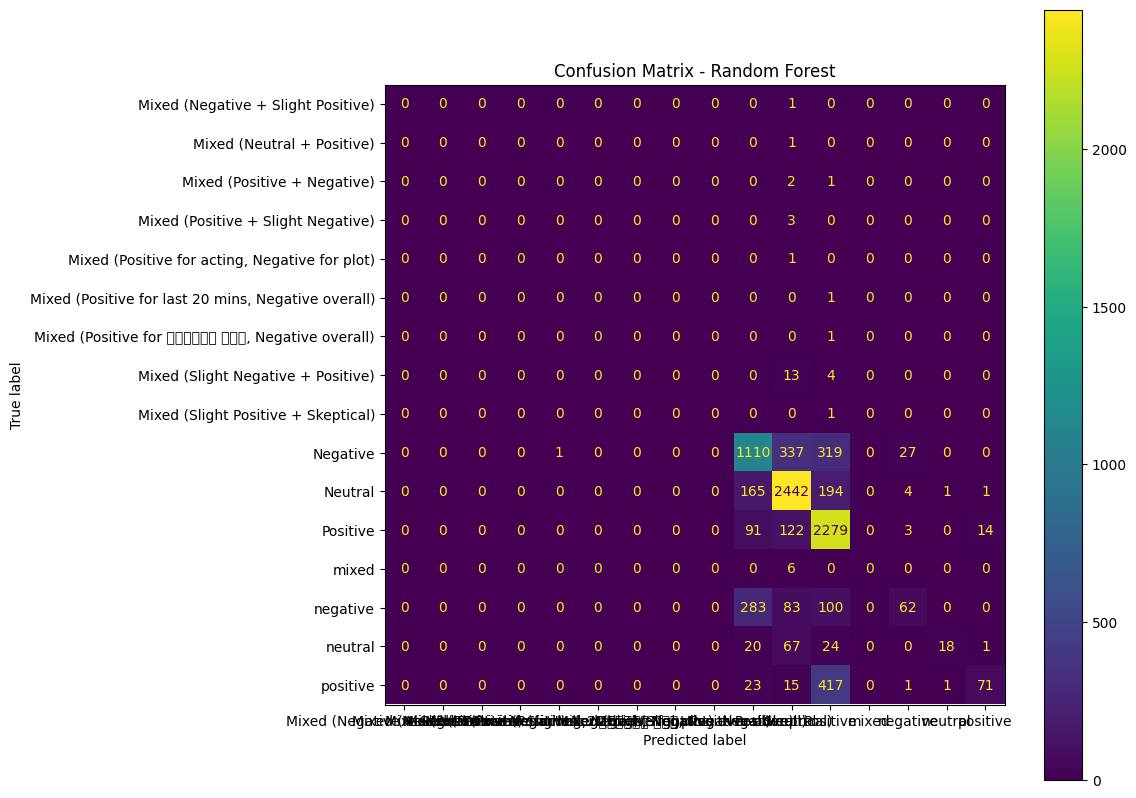

In [21]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

random_state = 42
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
    "Linear SVC": LinearSVC(random_state=random_state),
    "Random Forest": RandomForestClassifier(random_state=random_state)
}

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state)

for model_name, model in models.items():
  print(f"Model: {model_name}")
  print("-"*50)

  pipeline = Pipeline([
    ("tfidf", CountVectorizer(tokenizer=lambda x: x.split(), token_pattern=None)),
    ("model", model)
  ])

  y_pred = cross_val_predict(pipeline, X, y, cv=kfold)

  accuracy = accuracy_score(y, y_pred)
  precision = precision_score(y, y_pred, average='weighted')
  recall = recall_score(y, y_pred, average='weighted')
  f1 = f1_score(y, y_pred, average='weighted')

  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1 Score: {f1}")

  cm = confusion_matrix(y, y_pred)
  label = np.unique(y)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label)
  fig, ax = plt.subplots(figsize=(10,10))
  disp.plot(ax=ax)
  plt.title(f"Confusion Matrix - {model_name}")
  plt.savefig(f"confusion_matrix_{model_name}.png")
  plt.show()

## Conclusion & Key Takeaways

### Summary of Techniques Covered

| Step | Technique | Key Point |
|------|-----------|-----------|
| BoW (English) | `CountVectorizer` | Default tokenizer, works for ASCII text |
| BoW (Bengali) | `CountVectorizer` + custom tokenizer | Unicode-safe using `split()` |
| TF-IDF | `TfidfVectorizer` | Weights rare/informative terms higher |
| Pipeline | `sklearn.Pipeline` | Prevents data leakage between folds |
| Cross-Validation | `StratifiedKFold` | Balanced class splits across folds |
| Metrics | Accuracy, F1, Confusion Matrix | Multi-class evaluation |
| Model Comparison | LR vs SVM vs RF | Systematic best-model selection |

---

### **Key Takeaways**

1. **BoW is a strong baseline** — simple but surprisingly effective for text classification
2. **TF-IDF outperforms raw BoW** by penalizing common uninformative words
3. **Custom tokenizers** make scikit-learn work seamlessly with non-Latin scripts like Bengali
4. **Pipelines + Cross-Validation** are the gold standard for fair, leak-free model evaluation
5. **Linear SVC** often performs best on high-dimensional sparse text features
6. **Model comparison** is essential — always benchmark multiple algorithms before deploying



In [ ]:
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

random_state = 42
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=random_state),
    "Linear SVC": LinearSVC(random_state=random_state),
    "Random Forest": RandomForestClassifier(random_state=random_state)
}

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state)

for model_name, model in models.items():
  print(f"Model: {model_name}")
  print("-"*50)

  pipeline = Pipeline([
    ("tfidf", CountVectorizer(tokenizer=lambda x: x.split(), token_pattern=None)),
    ("model", model)
  ])

  y_pred = cross_val_predict(pipeline, X, y, cv=kfold)

  accuracy = accuracy_score(y, y_pred)
  precision = precision_score(y, y_pred, average='weighted')
  recall = recall_score(y, y_pred, average='weighted')
  f1 = f1_score(y, y_pred, average='weighted')

  print(f"Accuracy: {accuracy}")
  print(f"Precision: {precision}")
  print(f"Recall: {recall}")
  print(f"F1 Score: {f1}")

  cm = confusion_matrix(y, y_pred)
  label = np.unique(y)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label)
  fig, ax = plt.subplots(figsize=(10,10))
  disp.plot(ax=ax)
  plt.title(f"Confusion Matrix - {model_name}")
  plt.savefig(f"confusion_matrix_{model_name}.png")
  plt.show()

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pipeline = Pipeline([
    (
        "tfidf",
        CountVectorizer(
          tokenizer = lambda x: x.split(),
          token_pattern = None
      )
    ),
    (
        "model",
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced' )
    )
])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv = kfold
)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


# HW
Adding `class_weight=balanced`

In [25]:
y_pred

array(['Negative', 'Negative', 'positive', ..., 'negative', 'Neutral',
       'negative'], dtype=object)

In [26]:
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, average='weighted')
recall = recall_score(y, y_pred, average='weighted')
f1 = f1_score(y, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

Accuracy: 0.6643860280878646
Precision: 0.7046374920727435
Recall: 0.6643860280878646
F1 Score: 0.6802935911303029


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
